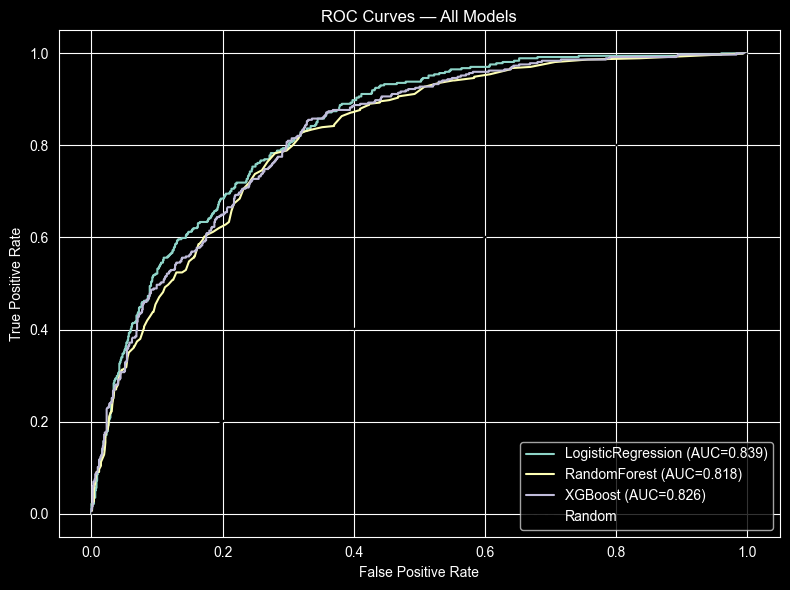

In [1]:
import sys
import os
sys.path.append('')
os.environ["MLFLOW_TRACKING_URI"] = "http://localhost:5000"

from src.train import train_all
from src.evaluate import evaluate_all, plot_roc_curves, plot_confusion_matrix

results, X_test, y_test = train_all('data/raw/telco_churn.csv')
metrics = evaluate_all(results, X_test, y_test)
plot_roc_curves(results, X_test, y_test)

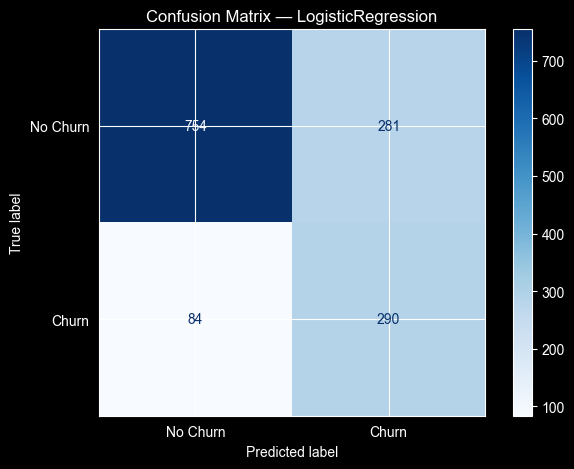

In [2]:
plot_confusion_matrix('LogisticRegression', results['LogisticRegression'], X_test, y_test)


In [ ]:
import shap
print(f"SHAP version: {shap.__version__}")

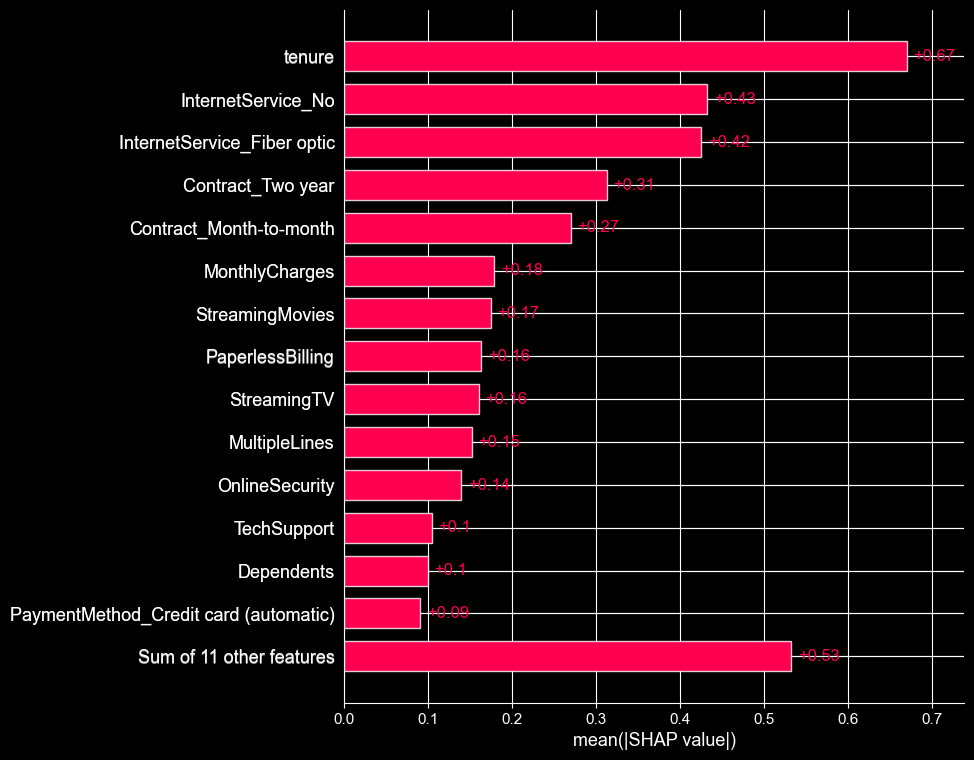

In [7]:
import shap
import matplotlib.pyplot as plt

model = results['LogisticRegression']

# Use generic Explainer — works better with scaled data
explainer = shap.Explainer(model, X_test)
shap_values = explainer(X_test)

# Bar plot — feature importance
shap.plots.bar(shap_values, max_display=15)

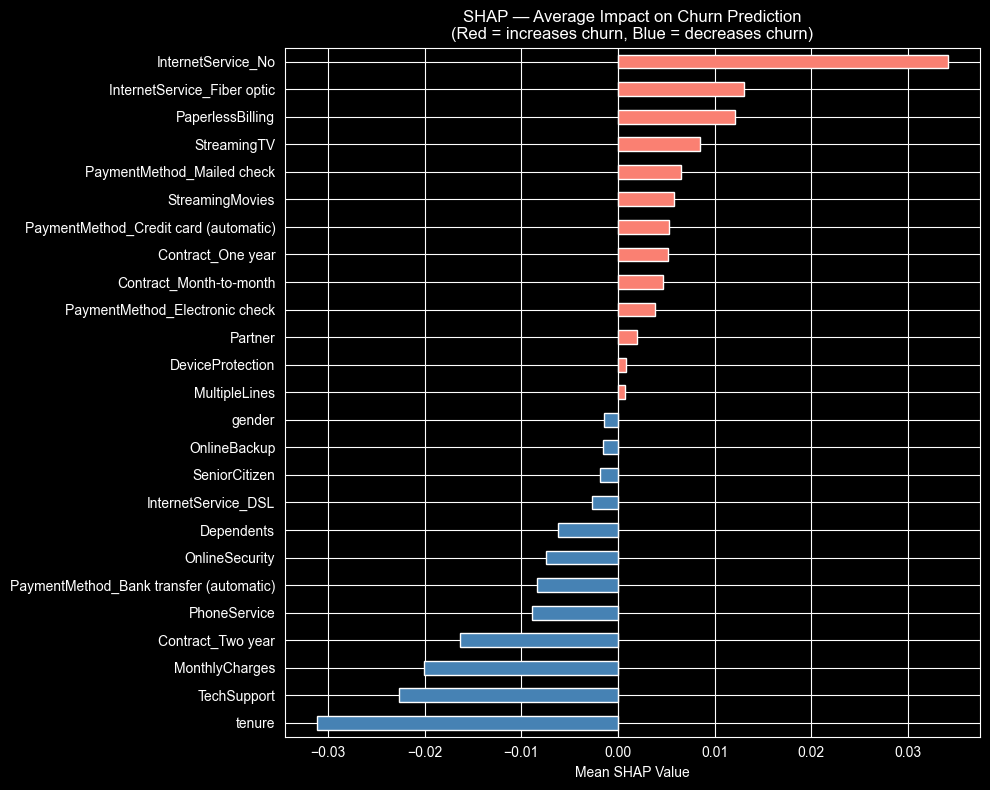

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Get mean SHAP values per feature
shap_df = pd.DataFrame(
    shap_values.values,
    columns=X_test.columns
)

mean_shap = shap_df.mean().sort_values()

colors = ['salmon' if v > 0 else 'steelblue' for v in mean_shap]

fig, ax = plt.subplots(figsize=(10, 8))
mean_shap.plot(kind='barh', ax=ax, color=colors)
ax.set_title('SHAP — Average Impact on Churn Prediction\n(Red = increases churn, Blue = decreases churn)')
ax.set_xlabel('Mean SHAP Value')
ax.axvline(0, color='white', linewidth=0.8)
plt.tight_layout()
plt.savefig('../reports/shap_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✅")